# Bayesian Network Visualization for Vulnerability Analysis

This notebook visualizes the results of Bayesian Network analysis on code vulnerability fixes. The analysis examines relationships between different types of code changes and their impact on vulnerability status.

In [ ]:
# Bayesian Network Visualization Pipeline for Vulnerability Analysis
# This notebook loads BN results, computes influence, visualizes, and exports results.
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import product
import os

# Try to import networkx, fallback to basic visualization
try:
    import networkx as nx
    HAS_NETWORKX = True
except ImportError:
    HAS_NETWORKX = False
    print("NetworkX not available, using basic network visualization")

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# Import project utilities
from megavul_diff_analysis.utils.config_utils import find_project_root

# --- Utility: Export figure ---
def export_figure(fig, name, subdir="figures"):
    project_root = find_project_root()
    out_dir = project_root / 'data' / 'results' / 'paper' / subdir
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{name}.png"
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Exported figure to {out_path}")
    return out_path

# --- Utility: Export DataFrame ---
def export_dataframe(df, name, subdir="tables"):
    project_root = find_project_root()
    out_dir = project_root / 'data' / 'results' / 'paper' / subdir
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{name}.csv"
    df.to_csv(out_path, index=False)
    print(f"Exported table to {out_path}")
    return out_path


## Load Bayesian Network Data

Load the Conditional Probability Distributions (CPDs) and network structure from the BN1 analysis results.

In [ ]:
# --- Load Bayesian Network Data ---
project_root = find_project_root()
results_dir = project_root / 'data' / 'results' / 'bn1' / 'bn1_hillclimb_mi50_tabu10_hcs'

# Load CPDs (Conditional Probability Distributions)
cpds_path = results_dir / 'bn1_hillclimb_mi50_tabu10_hcs_cpds.json'
with open(cpds_path, 'r') as f:
    cpds_data = json.load(f)

# Load network edges
edges_path = results_dir / 'bn1_hillclimb_mi50_tabu10_hcs_edges.json'
with open(edges_path, 'r') as f:
    edges_data = json.load(f)

print(f"Loaded {len(cpds_data)} CPDs and {len(edges_data)} edges")
print(f"Variables in the network: {[cpd['variable'] for cpd in cpds_data]}")

# Build networkx graph
if HAS_NETWORKX:
    G = nx.DiGraph()
    G.add_edges_from([(edge['source'], edge['target']) for edge in edges_data])


## Ancestor Subgraph Visualization


Visualize the subgraph of the Bayesian Network containing all ancestors of `is_vul` and the `is_vul` node itself. This shows the portion of the network that leads directly or indirectly to vulnerability, highlighting the causal structure.

In [ ]:
# --- Ancestor Subgraph Visualization ---
# Visualize the subgraph of the BN containing all ancestors of is_vul and export the figure
if HAS_NETWORKX:
    ancestors = list(nx.ancestors(G, 'is_vul'))
    topo_order = list(nx.topological_sort(G))
    ordered_ancestors = [v for v in topo_order if v in ancestors]
    sub_nodes = ordered_ancestors + ['is_vul']
    sub_edges = [(u, v) for u, v in G.edges() if u in sub_nodes and v in sub_nodes]
    G_sub = nx.DiGraph()
    G_sub.add_nodes_from(sub_nodes)
    G_sub.add_edges_from(sub_edges)
    fig2, ax2 = plt.subplots(figsize=(max(2.5, min(1.5 + 1.2*max(len(ordered_ancestors), 1), 8)), 2.5))
    pos = nx.spring_layout(G_sub, seed=42)
    nx.draw(G_sub, pos, with_labels=True, node_color=['lightblue' if v != 'is_vul' else 'salmon' for v in G_sub.nodes()],
            node_size=1200, font_size=10, font_weight='bold', arrows=True, arrowsize=15, edge_color='gray', width=2, ax=ax2)
    ax2.set_title('Ancestor Subgraph to is_vul', fontsize=12, fontweight='bold')
    ax2.axis('off')
    x_vals, y_vals = zip(*pos.values())
    x_range = max(x_vals) - min(x_vals)
    y_range = max(y_vals) - min(y_vals)
    left_pad = x_range * 0.22 + 0.22
    right_pad = x_range * 0.10 + 0.10
    y_pad = y_range * 0.25 + 0.2
    ax2.set_xlim(min(x_vals) - left_pad, max(x_vals) + right_pad)
    ax2.set_ylim(min(y_vals) - y_pad, max(y_vals) + y_pad)
    plt.tight_layout()
    export_figure(fig2, "ancestor_subgraph_is_vul")
    plt.show()
else:
    print('NetworkX is not available; cannot plot ancestor subgraph.')


## Direct Vulnerability Impact Analysis

Analyze which code changes have the strongest influence on vulnerability likelihood.

In [ ]:
# --- Direct Vulnerability Impact Analysis ---
# Analyze which code changes have the strongest influence on vulnerability likelihood and export the table/figure
vul_cpd = None
for cpd in cpds_data:
    if cpd['variable'] == 'is_vul':
        vul_cpd = cpd
        break
if vul_cpd:
    print("Variables directly influencing vulnerability:")
    print(f"Parents: {vul_cpd['parents']}")
    table = vul_cpd['table']
    df_vul = pd.DataFrame(table)
    vul_probs = []
    for _, row in df_vul.iterrows():
        parent_states = {k: v for k, v in row.items() if k != 'is_vul=0' and k != 'is_vul=1'}
        p_vul_0 = row.get('is_vul=0', 0)
        p_vul_1 = row.get('is_vul=1', 0)
        vul_probs.append({
            **parent_states,
            'P(Not Vulnerable)': p_vul_0,
            'P(Vulnerable)': p_vul_1
        })
    vul_df = pd.DataFrame(vul_probs)
    export_dataframe(vul_df, "vuln_parent_state_probs")
    if len(vul_df) <= 10:
        idx_cols = list(parent_states.keys())
        vul_df_idx = vul_df.set_index(idx_cols)
        ax = vul_df_idx.plot(
            kind='bar', stacked=True, figsize=(12, 6),
            color=['mediumseagreen', 'salmon']
        )
        plt.title('Vulnerability Probability by Parent State Combinations', fontsize=14)
        plt.ylabel('Probability')
        if idx_cols:
            plt.xlabel('(' + ', '.join(idx_cols) + ')')
        else:
            plt.xlabel('')
        plt.legend(title='Vulnerability Status')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        fig = ax.get_figure()
        export_figure(fig, "vuln_bar_chart")
        plt.show()
    else:
        print(f"Average P(Vulnerable): {vul_df['P(Vulnerable)'].mean():.3f}")
        print(f"Max P(Vulnerable): {vul_df['P(Vulnerable)'].max():.3f}")
        print(f"Min P(Vulnerable): {vul_df['P(Vulnerable)'].min():.3f}")


## Indirect Vulnerability Impact Analysis

This section examines how indirect (multi-step) relationships in the Bayesian Network contribute to the likelihood of a function being vulnerable. By tracing all possible paths from ancestor nodes to `is_vul`, we can quantify and visualize the cumulative influence of upstream code changes, even when their effects are mediated through intermediate variables. Tables and visualizations summarize the most influential indirect paths and their probability contributions to both vulnerable and non-vulnerable outcomes.


In [ ]:
# Build and export a table of probabilities for all ancestor states
def get_cpd_prob(var, state, assignment, cpd_lookup):
    cpd = cpd_lookup[var]
    parents = cpd.get("parents", [])
    table = cpd["table"]

    # Match the CPD row for the given parent assignment
    for row in table:
        if all(str(row[p]) == str(assignment[p]) for p in parents):
            return float(row[f"{var}={state}"])
    return np.nan

cpd_by_var = {cpd["variable"]: cpd for cpd in cpds_data}
ancestor_order = ordered_ancestors if "ordered_ancestors" in globals() else ancestor_nodes
binary_states = ["0", "1"]

rows = []
for states in product(binary_states, repeat=len(ancestor_order)):
    assign = dict(zip(ancestor_order, states))

    # Joint P(state)
    joint_prob = 1.0
    for var in ancestor_order:
        p = get_cpd_prob(var, assign[var], assign, cpd_by_var)
        joint_prob *= p

    # P(is_vul | state) using is_vul parents from assignment
    p_vul_1 = get_cpd_prob("is_vul", "1", assign, cpd_by_var)
    p_vul_0 = get_cpd_prob("is_vul", "0", assign, cpd_by_var)

    rows.append({
        **assign,
        "P(state)": joint_prob,
        "P(is_vul=0 | state)": p_vul_0,
        "P(is_vul=1 | state)": p_vul_1,
        "P(state, is_vul=0)": joint_prob * p_vul_0,
        "P(state, is_vul=1)": joint_prob * p_vul_1,
    })

ancestor_state_probs = pd.DataFrame(rows).sort_values("P(state)", ascending=False).reset_index(drop=True)
ancestor_state_probs_path = export_dataframe(ancestor_state_probs, "ancestor_state_probs")
print(f"Saved ancestor state probability table to {ancestor_state_probs_path}")
ancestor_state_probs

## Descendant Node Probabilities Conditioned on is_vul

This section computes $P(X \mid \text{is\_vul}=0)$ and $P(X \mid \text{is\_vul}=1)$ for each descendant node $X$ of `is_vul` in the learned DAG.

Notes:
- Descendants are all nodes reachable by following directed edges out of `is_vul`.
- These are probabilistic associations in the fitted BN structure and should not be over-interpreted as causal effects without additional assumptions.

In [ ]:
# Estimate P(descendant | is_vul=0/1) from CPDs via likelihood weighting
if not HAS_NETWORKX:
    print("NetworkX not available; cannot identify descendants.")
else:
    descendants = sorted(nx.descendants(G, "is_vul"))
    print(f"Descendant nodes of is_vul: {descendants}")

    if not descendants:
        descendant_conditional_probs = pd.DataFrame(
            columns=[
                "node",
                "state",
                "P(state=1 | is_vul=0)",
                "P(state=1 | is_vul=1)",
            ]
        )
    else:
        cpd_by_var = {cpd["variable"]: cpd for cpd in cpds_data}
        topo_order = list(nx.topological_sort(G))

        # Increase this for higher precision if runtime allows.
        n_samples = 4000

        def states_for_var(cpd, var):
            row0 = cpd["table"][0] if cpd.get("table") else {}
            state_keys = [k for k in row0.keys() if k.startswith(f"{var}=")]
            if state_keys:
                return [k.split("=", 1)[1] for k in state_keys]
            return ["0", "1"]

        state_space = {var: states_for_var(cpd_by_var[var], var) for var in topo_order}

        def row_probs(var, assignment):
            cpd = cpd_by_var[var]
            parents = cpd.get("parents", [])
            for row in cpd["table"]:
                if all(str(row[p]) == str(assignment[p]) for p in parents):
                    states = state_space[var]
                    probs = np.array([float(row[f"{var}={s}"]) for s in states], dtype=float)
                    total = probs.sum()
                    if total <= 0:
                        return states, np.ones(len(states)) / len(states)
                    return states, probs / total
            states = state_space[var]
            return states, np.ones(len(states)) / len(states)

        def likelihood_weighted_counts(evidence, n_draws=4000, seed=42):
            rng = np.random.default_rng(seed)
            counts = {node: {s: 0.0 for s in state_space[node]} for node in descendants}
            total_weight = 0.0

            for _ in range(n_draws):
                assignment = {}
                weight = 1.0

                for var in topo_order:
                    states, probs = row_probs(var, assignment)
                    if var in evidence:
                        ev_state = evidence[var]
                        if ev_state in states:
                            idx = states.index(ev_state)
                            weight *= probs[idx]
                            assignment[var] = ev_state
                        else:
                            weight = 0.0
                            break
                    else:
                        assignment[var] = rng.choice(states, p=probs)

                if weight <= 0:
                    continue

                total_weight += weight
                for node in descendants:
                    counts[node][assignment[node]] += weight

            return counts, total_weight

        counts_0, tw_0 = likelihood_weighted_counts({"is_vul": "0"}, n_draws=n_samples, seed=42)
        counts_1, tw_1 = likelihood_weighted_counts({"is_vul": "1"}, n_draws=n_samples, seed=43)

        rows = []
        for node in descendants:
            for state in state_space[node]:
                p0 = counts_0[node][state] / tw_0 if tw_0 > 0 else np.nan
                p1 = counts_1[node][state] / tw_1 if tw_1 > 0 else np.nan
                rows.append({
                    "node": node,
                    "state": state,
                    "P(state=1 | is_vul=0)": p0,
                    "P(state=1 | is_vul=1)": p1,
                    "delta_(is_vul=1-minus-0)": p1 - p0,
                })

        descendant_conditional_probs = pd.DataFrame(rows).sort_values(
            ["node", "state"]
        ).reset_index(drop=True)

    descendant_conditional_probs_path = export_dataframe(
        descendant_conditional_probs,
        "descendant_conditional_probs_given_is_vul"
    )
    print(f"Saved descendant conditional probability table to {descendant_conditional_probs_path}")
    descendant_conditional_probs

In [ ]:
# Use the exported CSV to rank descendant nodes by impact from is_vul
desc_csv = pd.read_csv(descendant_conditional_probs_path)

# For binary nodes, state=1 row is easiest to interpret as "presence" probability shift
state1 = desc_csv[desc_csv["state"].astype(str) == "1"].copy()
state1["abs_delta"] = state1["delta_(is_vul=1-minus-0)"].abs()
state1["impact_direction"] = np.where(
    state1["delta_(is_vul=1-minus-0)"] > 0,
    "higher when is_vul=1",
    "lower when is_vul=1"
)

most_impacted_descendants = (
    state1[["node", "P(state=1 | is_vul=0)", "P(state=1 | is_vul=1)", "abs_delta", "impact_direction"]]
    .sort_values("abs_delta", ascending=False)
    .reset_index(drop=True)
)

# Show top impacted nodes
top_n = 15
print(f"Top {top_n} descendant nodes most impacted by is_vul:")
display(most_impacted_descendants.head(top_n))

# Optional: export ranking
export_dataframe(most_impacted_descendants, "descendants_most_impacted_by_is_vul")

## Correlation Matrix Derived from CPDs

This section builds a variable correlation matrix directly from the fitted Bayesian Network CPDs.

Method:
- Use ancestral sampling from the learned DAG + CPD tables to generate synthetic draws.
- Convert sampled node states to numeric values.
- Compute a Pearson correlation matrix across sampled variables.

This is a model-implied association view (from CPDs), not an empirical correlation from raw source data.

In [ ]:
# Build a CPD-implied correlation matrix via ancestral sampling
cpd_by_var = {cpd["variable"]: cpd for cpd in cpds_data}

if HAS_NETWORKX:
    topo_order = list(nx.topological_sort(G))
else:
    # Fallback to CPD order if a DAG object is unavailable
    topo_order = [cpd["variable"] for cpd in cpds_data]


def states_for_var(cpd, var):
    row0 = cpd["table"][0] if cpd.get("table") else {}
    state_keys = [k for k in row0.keys() if k.startswith(f"{var}=")]
    if state_keys:
        return [k.split("=", 1)[1] for k in state_keys]
    return ["0", "1"]


state_space = {var: states_for_var(cpd_by_var[var], var) for var in topo_order}


def row_probs(var, assignment):
    cpd = cpd_by_var[var]
    parents = cpd.get("parents", [])
    for row in cpd["table"]:
        if all(str(row[p]) == str(assignment[p]) for p in parents):
            states = state_space[var]
            probs = np.array([float(row[f"{var}={s}"]) for s in states], dtype=float)
            total = probs.sum()
            if total <= 0:
                return states, np.ones(len(states)) / len(states)
            return states, probs / total
    states = state_space[var]
    return states, np.ones(len(states)) / len(states)


def ancestral_sample(n_draws=10000, seed=2026):
    rng = np.random.default_rng(seed)
    records = []
    for _ in range(n_draws):
        assignment = {}
        for var in topo_order:
            states, probs = row_probs(var, assignment)
            assignment[var] = rng.choice(states, p=probs)
        records.append(assignment)
    return pd.DataFrame(records)


sampled_df = ancestral_sample(n_draws=10000, seed=2026)

# Encode sampled states numerically for correlation computation
encoded_df = pd.DataFrame(index=sampled_df.index)
for col in sampled_df.columns:
    as_num = pd.to_numeric(sampled_df[col], errors="coerce")
    if as_num.notna().all():
        encoded_df[col] = as_num
    else:
        encoded_df[col] = pd.factorize(sampled_df[col])[0]

corr_matrix = encoded_df.corr(method="pearson")

corr_out = corr_matrix.reset_index().rename(columns={"index": "node"})
export_dataframe(corr_out, "cpd_implied_correlation_matrix")

corr_matrix.round(3)

In [ ]:
# Plot the correlation matrix as a heatmap
plt.figure(figsize=(21, 18))
ax = sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation", "pad": 0.01, "shrink": 0.965}
)
plt.title("CPD-Implied Correlation Matrix (Ancestral Sampling)", fontsize=24, fontweight='bold')
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)
ax.collections[0].colorbar.ax.tick_params(labelsize=12)
ax.collections[0].colorbar.set_label("Pearson correlation", fontsize=18)
plt.tight_layout()
export_figure(plt.gcf(), "cpd_implied_correlation_matrix")
plt.show()

## Ego Graph of the DAG with Probability Heatmap

This section visualizes a local ego graph of the Bayesian Network DAG, centered on `is_vul`.

What is shown:
- Nodes in the ego neighborhood (radius 2 by default).
- Node color encodes CPD-implied marginal probability $P(node=1)$ estimated via ancestral sampling.
- Warmer colors indicate higher estimated probability.

This gives a compact, probability-aware structural view of the DAG around the vulnerability node.

Exported figure to /home/katelyn/research-explaining_vuln_fixes/data/results/paper/figures/ego_graph_probability_heatmap.png


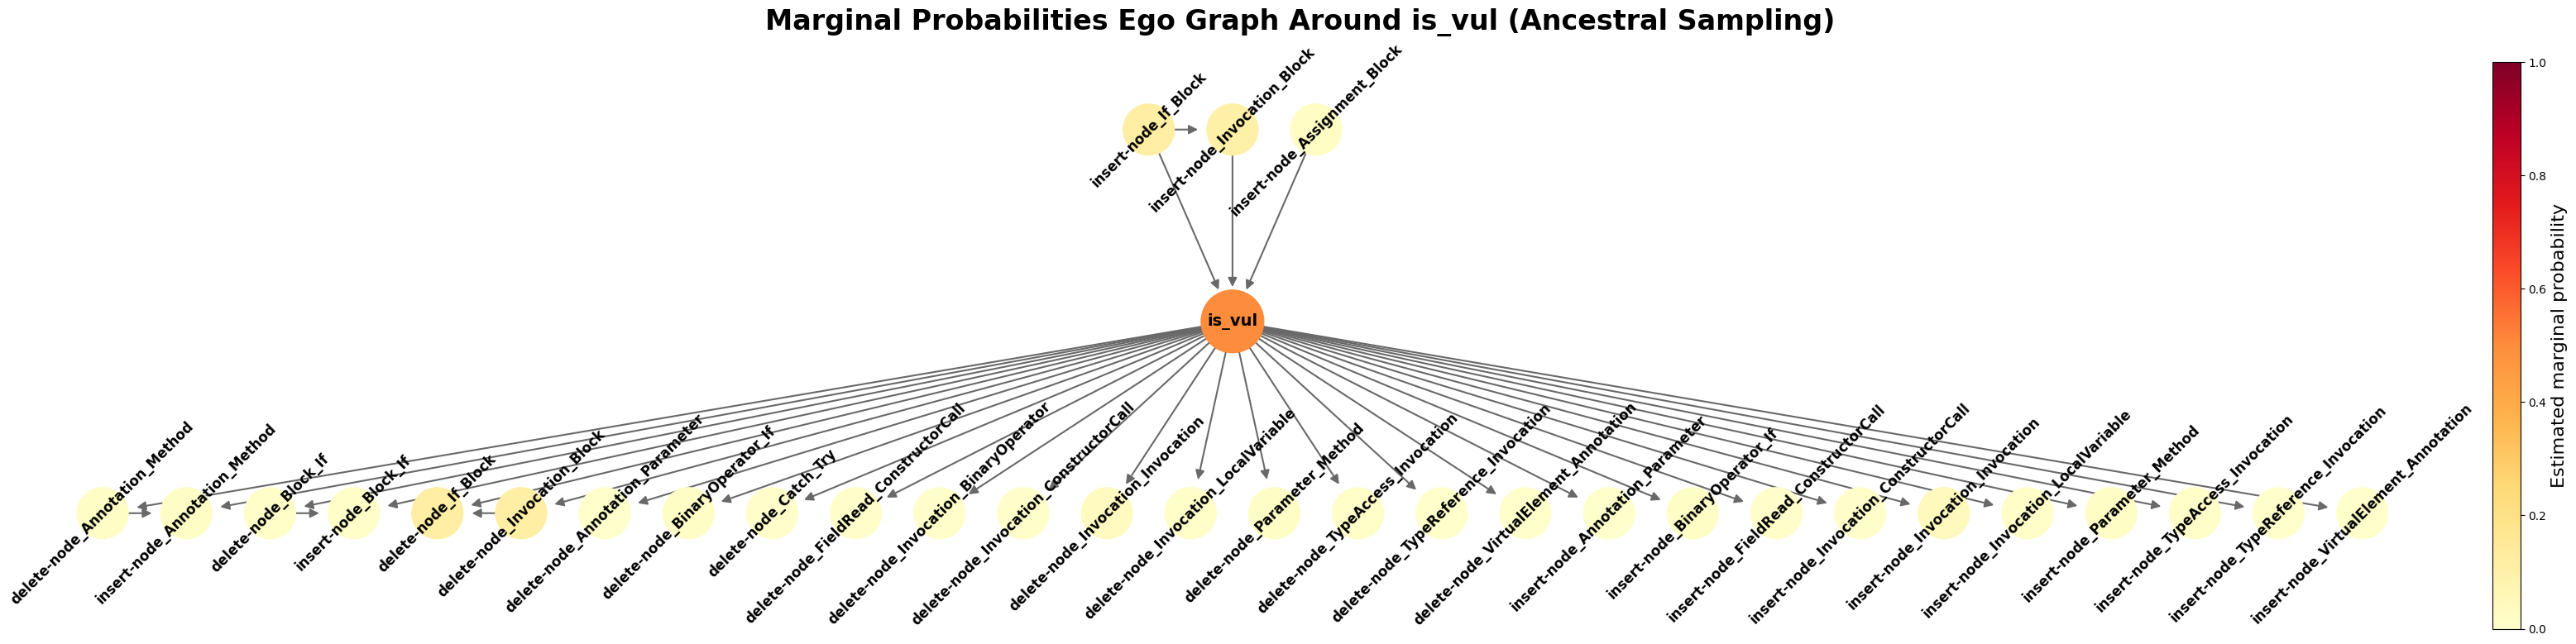

Exported table to /home/katelyn/research-explaining_vuln_fixes/data/results/paper/tables/ego_graph_probability_heatmap_table.csv


In [70]:
# Minimal ego graph plot around is_vul
if not HAS_NETWORKX:
    print("NetworkX not available; cannot plot ego graph.")
else:
    center_node = "is_vul" if "is_vul" in G.nodes else next(iter(G.nodes))
    radius = 1
    node_size_default = 2000
    node_size_center = 3000

    # Layout controls
    node_spacing_x = 2.6
    row_spacing_y = 0.4
    pad_left = 2.8
    pad_right = 0.8
    pad_top = 0.0
    pad_bottom = 0.1
    title_y = 0.955      # Move closer to 1.0 for less gap above plot
    layout_top = 0.985   # Tight layout top bound; increase to reduce title-node gap

    # Ego subgraph (undirected neighborhood, directed edges retained for drawing).
    ego_nodes = list(nx.ego_graph(G.to_undirected(), center_node, radius=radius).nodes())
    ego_dag = G.subgraph(ego_nodes).copy()

    # Use previously sampled_df if available; otherwise use neutral probabilities.
    if "sampled_df" in globals() and set(ego_nodes).issubset(set(sampled_df.columns)):
        node_probs = {
            n: float((sampled_df[n].astype(str) == "1").mean()) if (sampled_df[n].astype(str) == "1").any() else 0.5
            for n in ego_nodes
        }
    else:
        node_probs = {n: 0.5 for n in ego_nodes}

    # Place ancestors above, center node in the middle, descendants below.
    anc = sorted([n for n in ego_nodes if n != center_node and nx.has_path(ego_dag, n, center_node)])
    desc = sorted([n for n in ego_nodes if n != center_node and nx.has_path(ego_dag, center_node, n)])
    middle = sorted([n for n in ego_nodes if n not in set(anc) | set(desc) | {center_node}])

    def order_row_nodes(row_nodes, graph):
        """Group same-row connected nodes together to reduce overlap at that row."""
        if len(row_nodes) <= 1:
            return row_nodes

        row_set = set(row_nodes)
        row_graph = nx.Graph()
        row_graph.add_nodes_from(row_nodes)
        row_graph.add_edges_from(
            (u, v)
            for u, v in graph.edges()
            if u in row_set and v in row_set
        )

        components = [sorted(list(comp)) for comp in nx.connected_components(row_graph)]
        components.sort(key=lambda c: (-len(c), c[0]))

        ordered = []
        for comp in components:
            if len(comp) <= 2:
                ordered.extend(comp)
                continue

            # Inside a component, prefer higher in-row degree near center-like positions.
            deg = row_graph.degree(comp)
            comp_sorted = sorted(comp, key=lambda n: (-deg[n], n))
            ordered.extend(comp_sorted)

        return ordered

    anc = order_row_nodes(anc, ego_dag)
    middle = order_row_nodes(middle, ego_dag)
    desc = order_row_nodes(desc, ego_dag)

    def x_positions(nodes, step):
        if not nodes:
            return {}
        start = -0.5 * step * (len(nodes) - 1)
        return {node: start + i * step for i, node in enumerate(nodes)}

    pos = {}
    pos[center_node] = np.array([0.0, 0.0], dtype=float)
    for n, x in x_positions(anc, node_spacing_x).items():
        pos[n] = np.array([x, row_spacing_y], dtype=float)
    for n, x in x_positions(middle, node_spacing_x).items():
        pos[n] = np.array([x, 0.0], dtype=float)
    for n, x in x_positions(desc, node_spacing_x).items():
        pos[n] = np.array([x, -row_spacing_y], dtype=float)

    fig_w = max(9, 1.0 * max(len(ego_nodes), 6))
    fig_h = 8
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    draw_nodes = list(ego_dag.nodes())
    node_values = [node_probs[n] for n in draw_nodes]
    node_sizes = [node_size_center if n == center_node else node_size_default for n in draw_nodes]
    node_collection = nx.draw_networkx_nodes(
        ego_dag,
        pos,
        nodelist=draw_nodes,
        node_color=node_values,
        cmap=plt.cm.YlOrRd,
        vmin=0,
        vmax=1,
        node_size=node_sizes,
        linewidths=0.8,
        ax=ax,
    )

    nx.draw_networkx_edges(
        ego_dag,
        pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=16,
        width=1.5,
        min_source_margin=15,
        min_target_margin=30,
        edge_color="dimgray",
        ax=ax,
    )

    # Rotate non-center labels by 25 degrees.
    for n, (x, y) in pos.items():
        if n == center_node:
            ax.text(x, y, n, fontsize=14, fontweight="bold", ha="center", va="center", rotation=0)
        else:
            ax.text(x, y, n, fontsize=12, fontweight="bold", ha="center", va="center", rotation=45)

    # Graph padding controls around all positioned nodes.
    x_vals = [p[0] for p in pos.values()]
    y_vals = [p[1] for p in pos.values()]
    ax.set_xlim(min(x_vals) - pad_left, max(x_vals) + pad_right)

    # Include marker radius in y-limits so node circles are not clipped at top/bottom.
    fig.canvas.draw()
    max_node_size = max(node_sizes) if node_sizes else node_size_default
    node_radius_pts = float(np.sqrt(max_node_size / np.pi))
    node_radius_px = node_radius_pts * fig.dpi / 72.0
    y0 = ax.transData.inverted().transform((0, 0))[1]
    y1 = ax.transData.inverted().transform((0, node_radius_px))[1]
    marker_radius_y = abs(y1 - y0)
    y_extra = 1.15 * marker_radius_y
    ax.set_ylim(min(y_vals) - pad_bottom - y_extra, max(y_vals) + pad_top + y_extra)

    cbar = fig.colorbar(node_collection, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Estimated marginal probability", fontsize=16)

    # Use figure-level title to keep it centered even with colorbar + adjusted axes.
    fig.suptitle(
        f"Marginal Probabilities Ego Graph Around {center_node} (Ancestral Sampling)",
        fontsize=24,
        fontweight="bold",
        x=0.5,
        y=title_y,
        ha="center",
    )
    ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, layout_top])

    # Slightly increase colorbar height while preserving its center.
    cbar_pos = cbar.ax.get_position()
    grow = 1.12
    new_h = cbar_pos.height * grow
    new_y = cbar_pos.y0 - 0.5 * (new_h - cbar_pos.height)
    cbar.ax.set_position([cbar_pos.x0, new_y, cbar_pos.width, new_h])

    export_figure(fig, "ego_graph_probability_heatmap")
    plt.show()

    ego_prob_table = pd.DataFrame({
        "node": ego_nodes,
        "estimated_probability": [node_probs[n] for n in ego_nodes],
    }).sort_values("estimated_probability", ascending=False).reset_index(drop=True)

    export_dataframe(ego_prob_table, "ego_graph_probability_heatmap_table")
    ego_prob_table